In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# load processed data
X_train_scaled = pd.read_csv("X_train_scaled.csv")
X_test_scaled = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()



In [2]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Create model
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log= log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     41992
           1       0.17      0.73      0.27      3008

    accuracy                           0.74     45000
   macro avg       0.57      0.73      0.55     45000
weighted avg       0.92      0.74      0.80     45000

ROC AUC: 0.8007585284735087


In [3]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Create model
log_model = LogisticRegression(
    max_iter=1000
)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log= log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     41992
           1       0.57      0.01      0.02      3008

    accuracy                           0.93     45000
   macro avg       0.75      0.50      0.49     45000
weighted avg       0.91      0.93      0.90     45000

ROC AUC: 0.8007057543635464


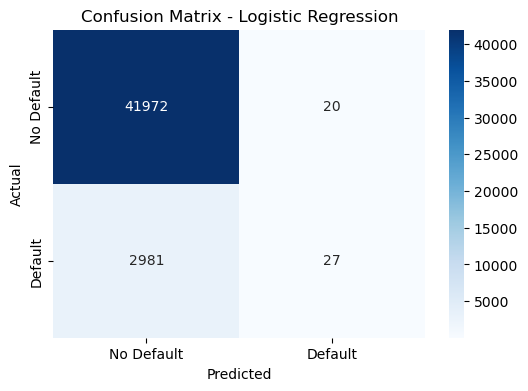

True Negatives: 41972
False Positives: 20
False Negatives: 2981
True Positives: 27


In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.9270888888888889

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     41992
           1       0.28      0.06      0.10      3008

    accuracy                           0.93     45000
   macro avg       0.61      0.52      0.53     45000
weighted avg       0.89      0.93      0.90     45000


Confusion Matrix:
 [[41543   449]
 [ 2832   176]]


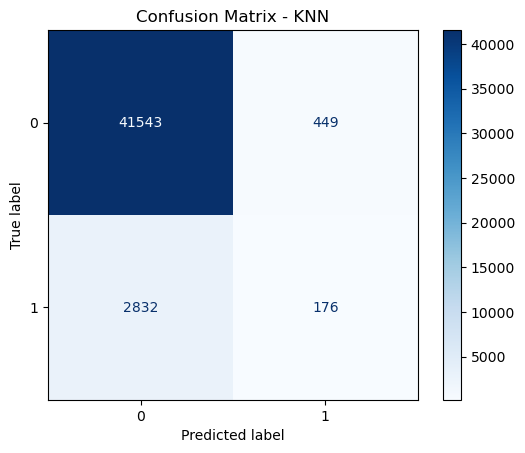

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - KNN")
plt.show()

In [7]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Create model
svm_model = LinearSVC(random_state=42)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9331555555555555

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     41992
           1       0.00      0.00      0.00      3008

    accuracy                           0.93     45000
   macro avg       0.47      0.50      0.48     45000
weighted avg       0.87      0.93      0.90     45000


Confusion Matrix:
 [[41992     0]
 [ 3008     0]]


/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

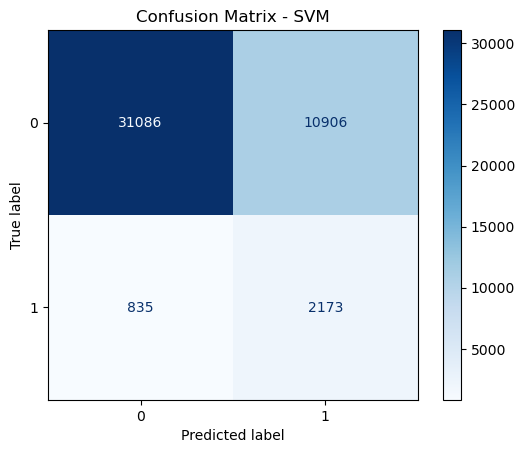

In [20]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SVM")
plt.show()

In [8]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Create model
svm_model = LinearSVC(random_state=42,class_weight='balanced')

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.7390888888888889

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.74      0.84     41992
           1       0.17      0.72      0.27      3008

    accuracy                           0.74     45000
   macro avg       0.57      0.73      0.56     45000
weighted avg       0.92      0.74      0.80     45000


Confusion Matrix:
 [[31086 10906]
 [  835  2173]]



Confusion Matrix:
 [[31086 10906]
 [  835  2173]]


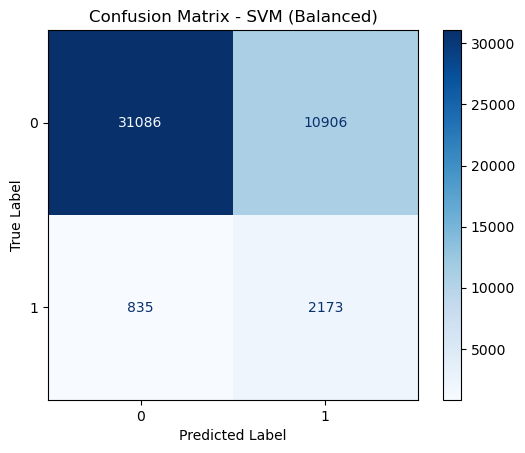

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SVM (Balanced)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
dt_model = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8852222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     41992
           1       0.16      0.17      0.17      3008

    accuracy                           0.89     45000
   macro avg       0.55      0.56      0.55     45000
weighted avg       0.89      0.89      0.89     45000


Confusion Matrix:
 [[39309  2683]
 [ 2482   526]]



Confusion Matrix:
 [[39257  2735]
 [ 2473   535]]


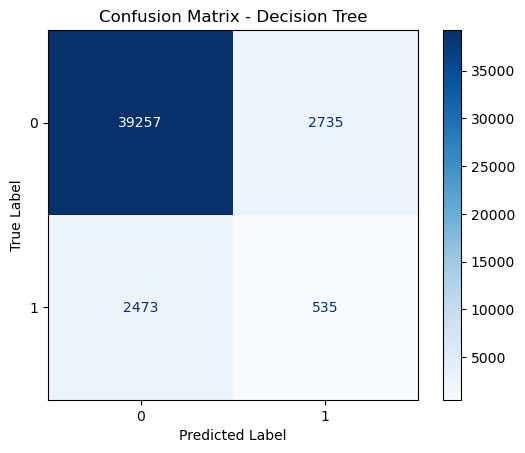

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8842666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94     41992
           1       0.16      0.18      0.17      3008

    accuracy                           0.88     45000
   macro avg       0.55      0.56      0.55     45000
weighted avg       0.89      0.88      0.89     45000


Confusion Matrix:
 [[39257  2735]
 [ 2473   535]]


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9331555555555555

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     41992
           1       0.00      0.00      0.00      3008

    accuracy                           0.93     45000
   macro avg       0.47      0.50      0.48     45000
weighted avg       0.87      0.93      0.90     45000


Confusion Matrix:
 [[41992     0]
 [ 3008     0]]


/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7772

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.78      0.87     41992
           1       0.18      0.67      0.29      3008

    accuracy                           0.78     45000
   macro avg       0.58      0.73      0.58     45000
weighted avg       0.92      0.78      0.83     45000


Confusion Matrix:
 [[32963  9029]
 [  997  2011]]



Confusion Matrix:
 [[32963  9029]
 [  997  2011]]


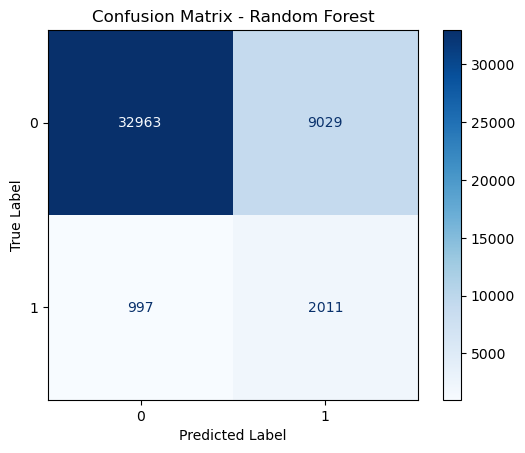

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9335333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     41992
           1       0.68      0.01      0.02      3008

    accuracy                           0.93     45000
   macro avg       0.81      0.51      0.49     45000
weighted avg       0.92      0.93      0.90     45000


Confusion Matrix:
 [[41977    15]
 [ 2976    32]]


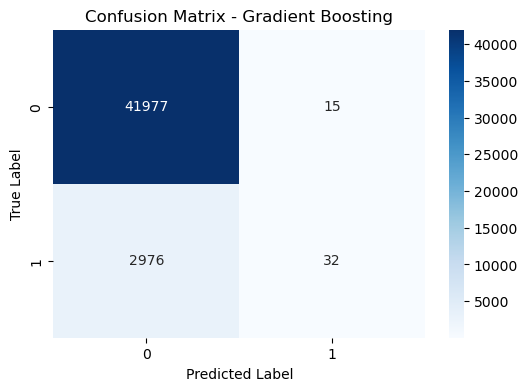

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # For binary classification
    eval_metric='logloss',        # Evaluation metric
    use_label_encoder=False,      # Avoid warning for new versions
    n_estimators=100,             # Number of trees
    learning_rate=0.1,            # Step size shrinkage
    max_depth=3,                  # Maximum tree depth
    random_state=42
)

# Fit the model
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb= xgb_model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for ROC-AUC

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/home/student/anaconda3/envs/ds/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [12:59:04] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     41992
           1       0.66      0.01      0.03      3008

    accuracy                           0.93     45000
   macro avg       0.80      0.51      0.50     45000
weighted avg       0.92      0.93      0.90     45000

ROC-AUC Score: 0.8077041864040466
Confusion Matrix:
 [[41971    21]
 [ 2967    41]]


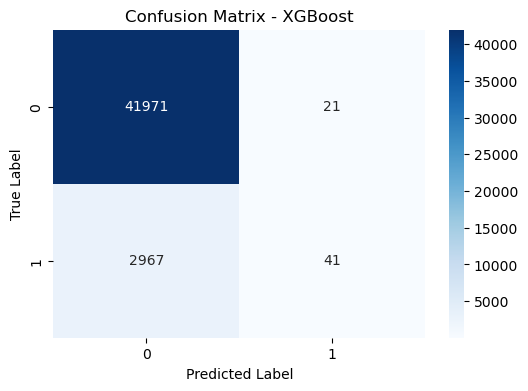

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM",
        "Random Forest",
        "Gradient Boosting",
        "xgboost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test,y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.933311
1        Decision Tree  0.884267
2                  KNN  0.927089
3                  SVM  0.739089
4        Random Forest  0.777200
5    Gradient Boosting  0.933533
6              xgboost  0.933600


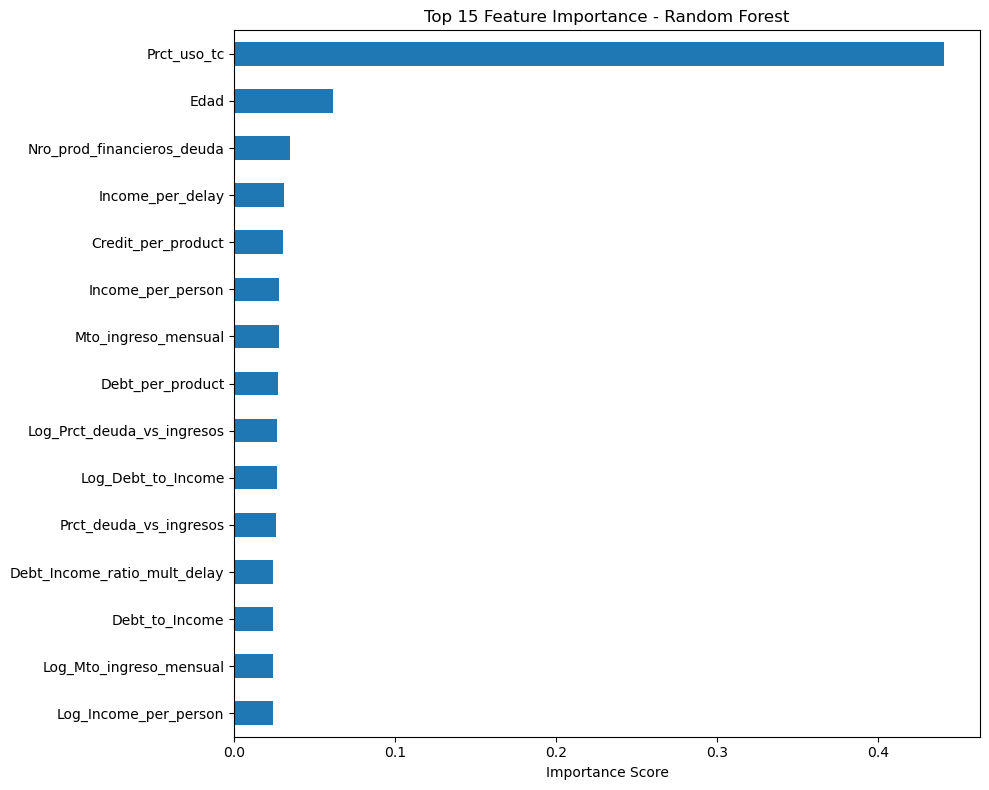

In [16]:
importance = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns)

top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

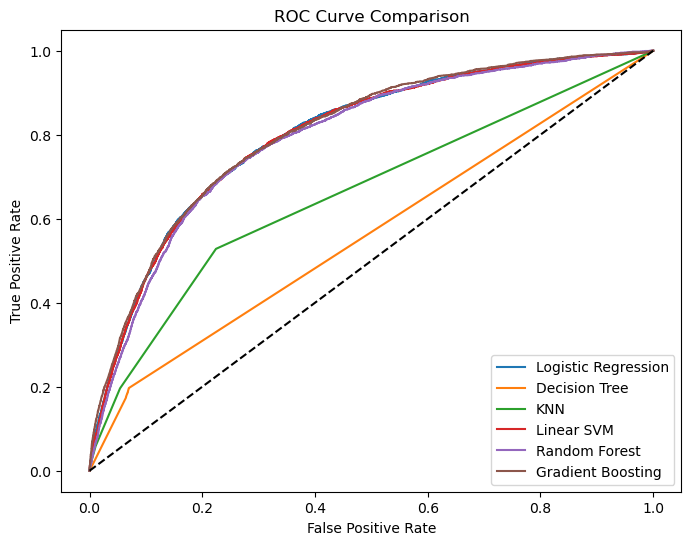

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.svm import LinearSVC

# Assuming your other models (log_model, dt_model, knn_model, rf_model, gb_model) are already fitted

# Linear SVM model
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Probability or decision scores for ROC
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]
y_score_svm = svm_model.decision_function(X_test_scaled)  # use decision_function for LinearSVC
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]
y_prob_xgb=xgb_model.predict_proba(X_test_scaled)[:, 1] 

# ROC calculations
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)  # note: decision_function used
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# Plotting
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_svm, tpr_svm, label="Linear SVM")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

# diagonal reference line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()